In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
from sklearn.preprocessing import LabelEncoder

In [3]:
df = sns.load_dataset('penguins') 

In [4]:
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [6]:
df['species'].unique()

array(['Adelie', 'Chinstrap', 'Gentoo'], dtype=object)

In [7]:
df[['species','island']].head(25)

,species,island
0,Adelie,Torgersen
1,Adelie,Torgersen
2,Adelie,Torgersen
3,Adelie,Torgersen
4,Adelie,Torgersen
5,Adelie,Torgersen
6,Adelie,Torgersen
7,Adelie,Torgersen
8,Adelie,Torgersen
9,Adelie,Torgersen


In [8]:
df[['species', 'island']].tail(25) 

,species,island
319,Gentoo,Biscoe
320,Gentoo,Biscoe
321,Gentoo,Biscoe
322,Gentoo,Biscoe
323,Gentoo,Biscoe
324,Gentoo,Biscoe
325,Gentoo,Biscoe
326,Gentoo,Biscoe
327,Gentoo,Biscoe
328,Gentoo,Biscoe


In [9]:
df.isna().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [10]:
df.groupby("sex")['body_mass_g'].mean()

sex
Female    3862.272727
Male      4545.684524
Name: body_mass_g, dtype: float64

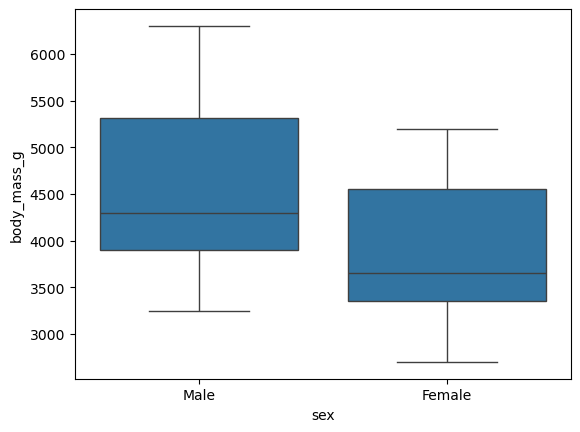

In [11]:
sns.boxplot(y = "body_mass_g", x ='sex',  data=df)
plt.show()

In [12]:
df["body_mass_g"] = df["body_mass_g"].fillna(df.groupby("sex")["body_mass_g"].transform("mean")) 

In [13]:
df[df.isna().any(axis=1)]

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,NaN
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN
246,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN
286,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN
324,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN
336,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,NaN


In [14]:
df.drop([3,339] , inplace=True)

In [15]:
df[df.isna().any(axis=1)] 

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,NaN
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN
246,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN
286,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN
324,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN
336,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,NaN


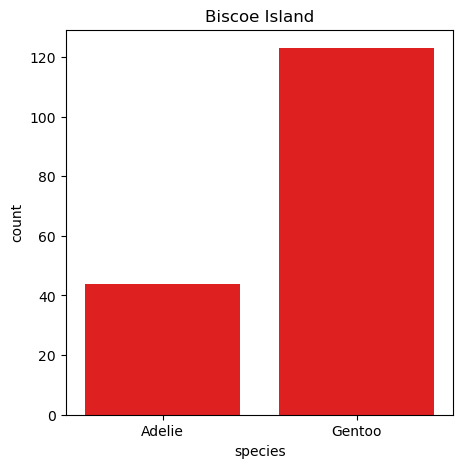

In [16]:
plt.figure(figsize=(5,5))
sns.countplot(data=df[df['island']=='Biscoe'], x = 'species', color = 'red')
plt.title('Biscoe Island')
plt.show()

**Gentoo penguins are more common than Adelie penguins on Biscoe Island.**

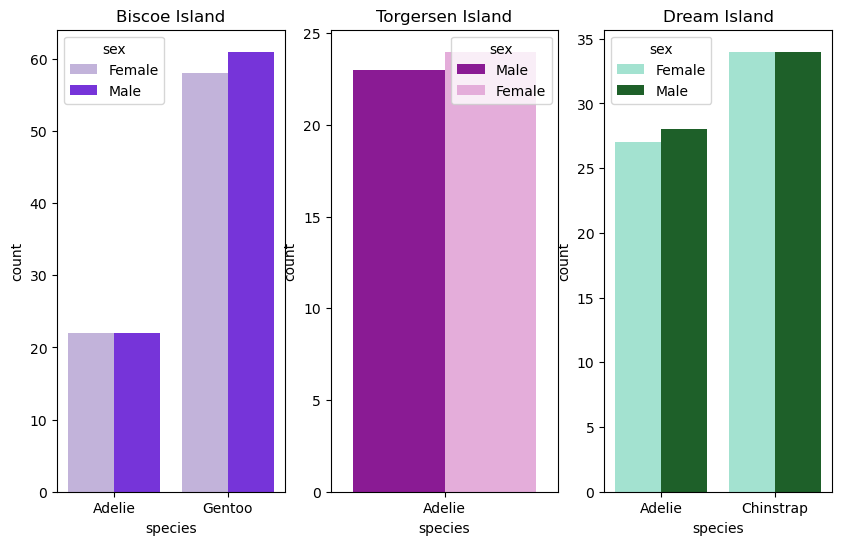

In [17]:
plt.figure(figsize=(10,6))

plt.subplot(1,3,1)
sns.countplot(data=df[df['island'] == 'Biscoe'], x = 'species' , hue = 'sex', palette = {'Female':'#c1ade0', 'Male':'#7118f5'})
plt.title('Biscoe Island')

plt.subplot(1,3,2)
sns.countplot(data=df[df['island']== 'Torgersen'] , x = 'species' , hue = 'sex', palette = {'Male':'#9b07a8', 'Female':'#eda4e0'})
plt.title('Torgersen Island')

plt.subplot(1,3,3)
sns.countplot(data=df[df['island']== 'Dream'], x = 'species', hue = 'sex', palette = {'Female':'#98edd4', 'Male':'#136b22'})
plt.title('Dream Island')
plt.show()

In [18]:
df_one_hot = pd.get_dummies(df, columns = ['sex'], drop_first=True)

In [19]:
df_one_hot

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex_Male
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,True
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,False
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,False
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,False
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,True
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,False
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,False
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,True
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,False


In [20]:
df_label = df.copy()
l = LabelEncoder()

In [21]:
df_label['sex'] = l.fit_transform(df_label['sex'])

In [22]:
df_label

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,1
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,0
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,0
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,0
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,1
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,0
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,0
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,1
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,0


In [23]:
df_new = df.dropna(axis = 0)
df_new

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


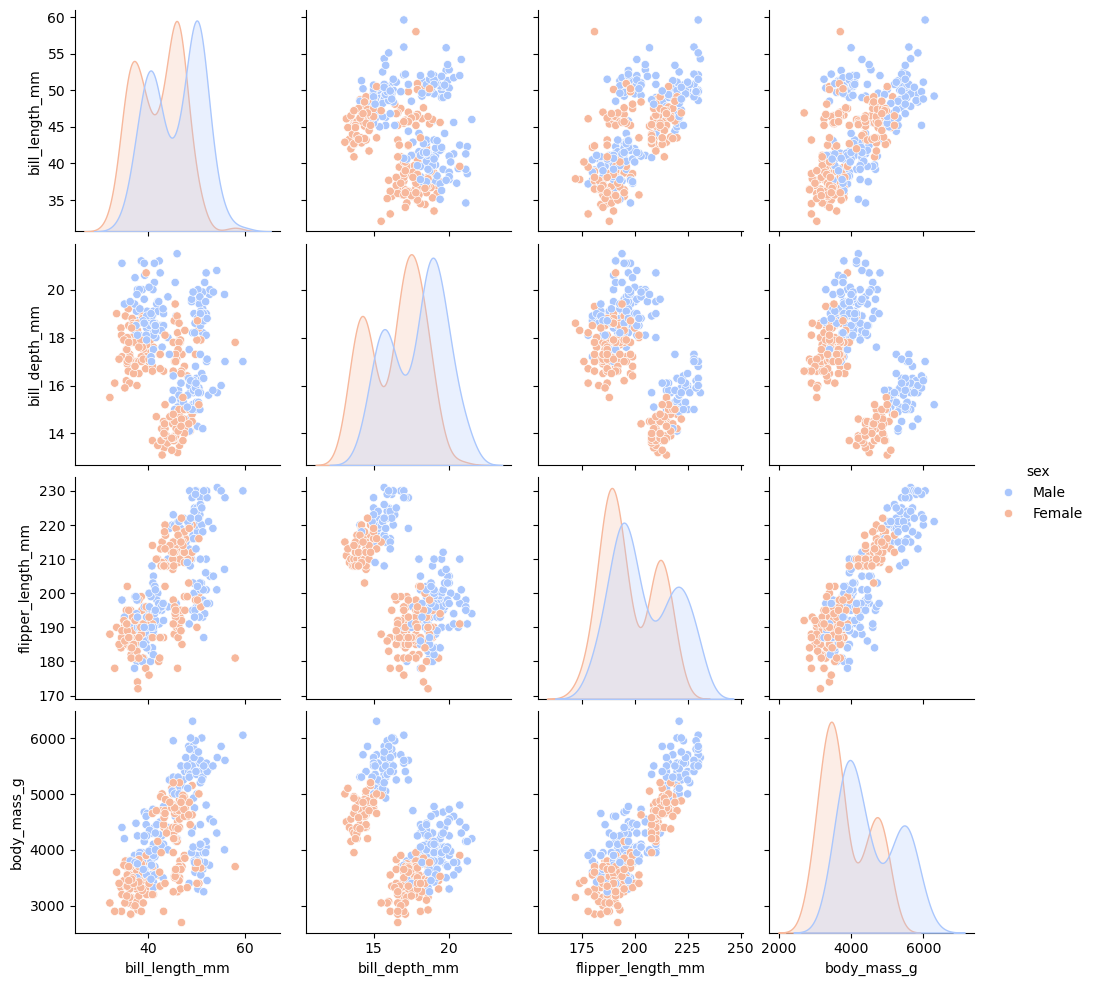

In [24]:
sns.pairplot(data= df_new, hue = 'sex', palette = "coolwarm")
plt.show()

1. **Penguins with higher body weight tend to have narrower bills.**
2. **There is a linear relationship between flipper length and body weight.**
3. **Penguins with longer flippers generally tend to have longer bills.**
4. **Penguins with longer flippers tend to have narrower bills; this was seen in about 65% of the cluster.**
5. **No direct relationship was found between bill length and bill depth.**

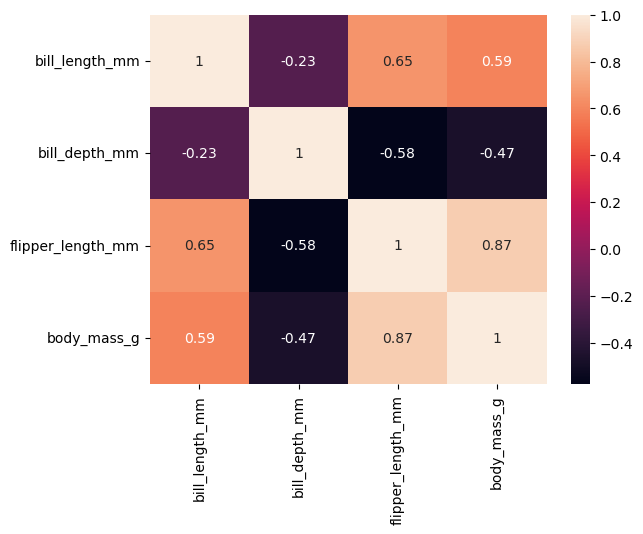

In [25]:
sns.heatmap(df_new.corr(numeric_only = True), annot = True)
plt.show()

 **The correlation table confirmed the accuracy of the five predictions I made from the graphs**